In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

# XGBoost üçün (əgər quraşdırılmayıbsa, terminalda: pip install xgboost)
from xgboost import XGBClassifier

rng = np.random.default_rng(42)

# Synthetic data parametrləri
N_MARKETS = 60          # neçə market
N_STEPS = 500           # hər market üçün neçə saatlıq data
START_DATE = "2025-01-01"
FREQ = "1h"

print("Setup ready ✅")

Setup ready ✅


In [5]:
# Fayl path-ları öz layihənə uyğun dəyiş
price_path = r"C:\Users\HP\Desktop\PredictBack\predicthub_backend\ml\synthetic\price_history.csv"
trades_path = r"C:\Users\HP\Desktop\PredictBack\predicthub_backend\ml\synthetic\trades.csv"
liq_path = r"C:\Users\HP\Desktop\PredictBack\predicthub_backend\ml\synthetic\liquidity_events.csv"

df_price = pd.read_csv(price_path, parse_dates=["timestamp"])
df_trades = pd.read_csv(trades_path, parse_dates=["created_at"])
df_liq = pd.read_csv(liq_path, parse_dates=["created_at"])

df_price.head()


,id,market_id,yes_price,no_price,timestamp
0,372,30,0.483820,0.516180,2025-12-01 13:04:53.037572+00:00
1,371,30,0.518666,0.481334,2025-12-01 08:04:53.037572+00:00
2,107,18,0.428595,0.571405,2025-12-01 01:04:51.908383+00:00
3,370,30,0.532890,0.467110,2025-11-30 23:04:53.037572+00:00
4,369,30,0.499639,0.500361,2025-11-30 16:04:53.037572+00:00


In [6]:
price_rows = []

for market_id in range(1, N_MARKETS + 1):
    ts = pd.date_range(start=START_DATE, periods=N_STEPS, freq=FREQ)

    # Market üçün rejim və volatility seç
    regime = rng.choice(["trend_up", "trend_down", "sideway"], p=[0.4, 0.3, 0.3])
    volatility = rng.uniform(0.02, 0.06)

    # Başlanğıc YES ehtimalı
    yes_price = rng.uniform(0.3, 0.7)

    for t in ts:
        # Drift
        if regime == "trend_up":
            mu = rng.uniform(0.0005, 0.004)
        elif regime == "trend_down":
            mu = rng.uniform(-0.004, -0.0005)
        else:  # sideway
            mu = rng.uniform(-0.0015, 0.0015)

        noise = rng.normal(0, volatility)
        yes_price = yes_price * np.exp(mu + noise)
        yes_price = float(np.clip(yes_price, 0.05, 0.95))
        no_price = 1.0 - yes_price

        price_rows.append({
            "market_id": market_id,
            "timestamp": t,
            "yes_price": yes_price,
            "no_price": no_price,
            "regime": regime
        })

price_history = pd.DataFrame(price_rows)
price_history = price_history.sort_values(["market_id", "timestamp"]).reset_index(drop=True)

print("price_history:", price_history.shape)
price_history.head()

price_history: (30000, 5)


,market_id,timestamp,yes_price,no_price,regime
0,1,2025-01-01 00:00:00,0.598333,0.401667,sideway
1,1,2025-01-01 01:00:00,0.602071,0.397929,sideway
2,1,2025-01-01 02:00:00,0.602208,0.397792,sideway
3,1,2025-01-01 03:00:00,0.622336,0.377664,sideway
4,1,2025-01-01 04:00:00,0.624681,0.375319,sideway


In [7]:
trade_rows = []

user_pool = np.arange(1, 1000)  # yalnız trade üçün lazımdır, ayrı user cədvəli yaratmırıq

for _, row in price_history.iterrows():
    market_id = row["market_id"]
    t = row["timestamp"]
    yes_p = row["yes_price"]

    # price 0.5 civarında olanda volume çox, uc və ya aşağıda olanda az
    expected_trades = 1.0 + 10.0 * (0.5 - abs(yes_p - 0.5))  # max ~6
    n_trades = rng.poisson(expected_trades)

    for _ in range(n_trades):
        user_id = int(rng.choice(user_pool))
        amount = float(rng.uniform(5, 300))

        # outcome - YES ehtimalı price ilə korrelyasiyalı
        prob_yes = np.clip(yes_p + rng.normal(0, 0.05), 0.05, 0.95)
        outcome = "YES" if rng.random() < prob_yes else "NO"

        trade_rows.append({
            "market_id": market_id,
            "timestamp": t,
            "user_id": user_id,
            "outcome": outcome,
            "amount": amount,
            "yes_price_at_trade": yes_p
        })

trades = pd.DataFrame(trade_rows)
trades = trades.sort_values(["market_id", "timestamp"]).reset_index(drop=True)

print("trades:", trades.shape)
trades.head()

trades: (117563, 6)


,market_id,timestamp,user_id,outcome,amount,yes_price_at_trade
0,1,2025-01-01,121,YES,32.659345,0.598333
1,1,2025-01-01,869,NO,126.687405,0.598333
2,1,2025-01-01,649,YES,145.792488,0.598333
3,1,2025-01-01,670,YES,230.416215,0.598333
4,1,2025-01-01,631,YES,153.319202,0.598333


In [9]:
liq_rows = []

for market_id in range(1, N_MARKETS + 1):
    n_events = rng.integers(30, 80)

    ts = price_history.loc[price_history.market_id == market_id, "timestamp"].values
    if len(ts) == 0:
        continue

    for _ in range(n_events):
        t = rng.choice(ts)
        event_type = rng.choice(["ADD", "REMOVE"], p=[0.7, 0.3])
        amount = float(rng.uniform(50, 1000))

        liq_rows.append({
            "market_id": market_id,
            "timestamp": t,
            "event_type": event_type,
            "amount": amount
        })

liquidity_events = pd.DataFrame(liq_rows)
liquidity_events = liquidity_events.sort_values(["market_id", "timestamp"]).reset_index(drop=True)

print("liquidity_events:", liquidity_events.shape)
liquidity_events.head()

liquidity_events: (3222, 4)


,market_id,timestamp,event_type,amount
0,1,2025-01-01 03:00:00,ADD,924.425289
1,1,2025-01-01 05:00:00,ADD,146.423748
2,1,2025-01-01 10:00:00,ADD,967.248921
3,1,2025-01-01 22:00:00,ADD,764.156513
4,1,2025-01-01 23:00:00,ADD,95.211301


In [10]:
HORIZON = 3      # 3 saat sonranı proqnozlaşdırırıq
EPS = 0.02       # 2% change threshold

# price_history-də YES price-ın shifted variantını hesablayırıq
def compute_target(df):
    df = df.sort_values("timestamp").copy()
    df["yes_future"] = df["yes_price"].shift(-HORIZON)
    df["pct_change"] = (df["yes_future"] - df["yes_price"]) / df["yes_price"]

    conditions = [
        df["pct_change"] > EPS,
        df["pct_change"] < -EPS
    ]
    choices = ["UP", "DOWN"]
    df["target"] = np.select(conditions, choices, default="FLAT")
    return df

ph_with_target = (
    price_history
    .groupby("market_id", group_keys=False)
    .apply(compute_target)
)

# Son HORIZON bar üçün future məlumat yoxdur → drop edirik
ph_with_target = ph_with_target.dropna(subset=["yes_future"])

print(ph_with_target[["market_id","timestamp","yes_price","yes_future","pct_change","target"]].head(10))

print("Target paylanması:")
print(ph_with_target["target"].value_counts(normalize=True))

   market_id           timestamp  yes_price  yes_future  pct_change target
0          1 2025-01-01 00:00:00   0.598333    0.622336    0.040116     UP
1          1 2025-01-01 01:00:00   0.602071    0.624681    0.037552     UP
2          1 2025-01-01 02:00:00   0.602208    0.636361    0.056713     UP
3          1 2025-01-01 03:00:00   0.622336    0.644707    0.035947     UP
4          1 2025-01-01 04:00:00   0.624681    0.665460    0.065280     UP
5          1 2025-01-01 05:00:00   0.636361    0.661117    0.038902     UP
6          1 2025-01-01 06:00:00   0.644707    0.691876    0.073163     UP
7          1 2025-01-01 07:00:00   0.665460    0.681639    0.024313     UP
8          1 2025-01-01 08:00:00   0.661117    0.694766    0.050898     UP
9          1 2025-01-01 09:00:00   0.691876    0.704654    0.018468   FLAT
Target paylanması:
target
DOWN    0.386318
UP      0.359557
FLAT    0.254125
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_7432\1904293511.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_target)


In [11]:
# STEP 5.1: Trade agregasiyası

trades_agg = (
    trades
    .groupby(["market_id", "timestamp"])
    .agg(
        trade_count=("amount", "count"),
        volume_total=("amount", "sum"),
        volume_yes=("amount", lambda x: x[trades.loc[x.index, "outcome"]=="YES"].sum()),
        volume_no=("amount", lambda x: x[trades.loc[x.index, "outcome"]=="NO"].sum()),
    )
    .reset_index()
)

trades_agg["trade_imbalance"] = (
    (trades_agg["volume_yes"] - trades_agg["volume_no"]) /
    (trades_agg["volume_total"] + 1e-6)
)

print("trades_agg:", trades_agg.shape)
trades_agg.head()

trades_agg: (28641, 7)


,market_id,timestamp,trade_count,volume_total,volume_yes,volume_no,trade_imbalance
0,1,2025-01-01 00:00:00,5,688.874655,562.187250,126.687405,0.632190
1,1,2025-01-01 01:00:00,7,869.835632,619.169524,250.666108,0.423647
2,1,2025-01-01 02:00:00,4,632.571668,481.389192,151.182475,0.522007
3,1,2025-01-01 03:00:00,4,581.171875,553.425776,27.746099,0.904517
4,1,2025-01-01 04:00:00,4,791.883805,508.888573,282.995231,0.285261


In [12]:
# STEP 5.2: Liquidity agregasiyası

liquidity_events["liq_add"] = np.where(liquidity_events["event_type"]=="ADD",
                                      liquidity_events["amount"], 0.0)
liquidity_events["liq_remove"] = np.where(liquidity_events["event_type"]=="REMOVE",
                                          liquidity_events["amount"], 0.0)

liq_agg = (
    liquidity_events
    .groupby(["market_id", "timestamp"])
    .agg(
        liq_add=("liq_add", "sum"),
        liq_remove=("liq_remove", "sum")
    )
    .reset_index()
)

print("liq_agg:", liq_agg.shape)
liq_agg.head()

liq_agg: (3062, 4)


,market_id,timestamp,liq_add,liq_remove
0,1,2025-01-01 03:00:00,924.425289,0.0
1,1,2025-01-01 05:00:00,146.423748,0.0
2,1,2025-01-01 10:00:00,967.248921,0.0
3,1,2025-01-01 22:00:00,764.156513,0.0
4,1,2025-01-01 23:00:00,95.211301,0.0


In [13]:
# STEP 5.3: price + trades + liquidity merge

df = ph_with_target.merge(trades_agg, on=["market_id","timestamp"], how="left")
df = df.merge(liq_agg, on=["market_id","timestamp"], how="left")

# NaN-ları 0 ilə dolduraq (həmin anda trade/liquidity olmayıbsa)
for col in ["trade_count", "volume_total", "volume_yes", "volume_no",
            "trade_imbalance", "liq_add", "liq_remove"]:
    df[col] = df[col].fillna(0.0)

df.head()

,market_id,timestamp,yes_price,no_price,regime,yes_future,pct_change,target,trade_count,volume_total,volume_yes,volume_no,trade_imbalance,liq_add,liq_remove
0,1,2025-01-01 00:00:00,0.598333,0.401667,sideway,0.622336,0.040116,UP,5.0,688.874655,562.187250,126.687405,0.632190,0.000000,0.0
1,1,2025-01-01 01:00:00,0.602071,0.397929,sideway,0.624681,0.037552,UP,7.0,869.835632,619.169524,250.666108,0.423647,0.000000,0.0
2,1,2025-01-01 02:00:00,0.602208,0.397792,sideway,0.636361,0.056713,UP,4.0,632.571668,481.389192,151.182475,0.522007,0.000000,0.0
3,1,2025-01-01 03:00:00,0.622336,0.377664,sideway,0.644707,0.035947,UP,4.0,581.171875,553.425776,27.746099,0.904517,924.425289,0.0
4,1,2025-01-01 04:00:00,0.624681,0.375319,sideway,0.665460,0.065280,UP,4.0,791.883805,508.888573,282.995231,0.285261,0.000000,0.0


In [14]:
# STEP 5.4: Rolling & lag-based features (leakage olmadan)

def add_rolling_features(group):
    group = group.sort_values("timestamp").copy()
    
    # Lag returns
    group["ret_1h"] = group["yes_price"].pct_change(1)
    group["ret_3h"] = group["yes_price"].pct_change(3)
    group["ret_6h"] = group["yes_price"].pct_change(6)
    
    # Rolling volatility (std of returns)
    group["vol_6h"] = group["ret_1h"].rolling(window=6, min_periods=3).std()
    group["vol_24h"] = group["ret_1h"].rolling(window=24, min_periods=6).std()
    
    # Rolling trade/liquidity sums (6h pəncərə)
    group["volume_total_6h"] = group["volume_total"].rolling(window=6, min_periods=1).sum()
    group["volume_yes_6h"] = group["volume_yes"].rolling(window=6, min_periods=1).sum()
    group["volume_no_6h"] = group["volume_no"].rolling(window=6, min_periods=1).sum()
    
    group["liq_add_6h"] = group["liq_add"].rolling(window=6, min_periods=1).sum()
    group["liq_remove_6h"] = group["liq_remove"].rolling(window=6, min_periods=1).sum()
    group["net_liq_6h"] = group["liq_add_6h"] - group["liq_remove_6h"]
    
    return group

df_feat = df.groupby("market_id", group_keys=False).apply(add_rolling_features)

# İlk barlarda NaN olanlar (rolling ucbatından) drop edək
df_feat = df_feat.dropna(subset=["ret_1h", "ret_3h", "ret_6h", "vol_6h", "vol_24h"])

print("df_feat shape:", df_feat.shape)
df_feat.head()

df_feat shape: (29460, 26)


C:\Users\HP\AppData\Local\Temp\ipykernel_7432\3243215152.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_feat = df.groupby("market_id", group_keys=False).apply(add_rolling_features)


,market_id,timestamp,yes_price,no_price,regime,yes_future,pct_change,target,trade_count,volume_total,...,ret_3h,ret_6h,vol_6h,vol_24h,volume_total_6h,volume_yes_6h,volume_no_6h,liq_add_6h,liq_remove_6h,net_liq_6h
6,1,2025-01-01 06:00:00,0.644707,0.355293,sideway,0.691876,0.073163,UP,6.0,1102.223240,...,0.035947,0.077505,0.012186,0.012186,4137.953867,2847.441824,1290.512043,1070.849036,0.0,1070.849036
7,1,2025-01-01 07:00:00,0.665460,0.334540,sideway,0.681639,0.024313,UP,4.0,427.659428,...,0.065280,0.105284,0.013963,0.013367,3695.777662,2430.472606,1265.305056,1070.849036,0.0,1070.849036
8,1,2025-01-01 08:00:00,0.661117,0.338883,sideway,0.694766,0.050898,UP,4.0,554.944343,...,0.038902,0.097821,0.015736,0.014600,3618.150337,2260.434374,1357.715963,1070.849036,0.0,1070.849036
9,1,2025-01-01 09:00:00,0.691876,0.308124,sideway,0.704654,0.018468,FLAT,0.0,0.000000,...,0.073163,0.111740,0.019202,0.017722,3036.978463,1707.008598,1329.969865,146.423748,0.0,146.423748
10,1,2025-01-01 10:00:00,0.681639,0.318361,sideway,0.764090,0.120960,UP,4.0,612.363787,...,0.024313,0.091180,0.023055,0.019405,2857.458445,1275.302332,1582.156113,1113.672669,0.0,1113.672669


In [15]:
feature_cols = [
    # price
    "yes_price",
    "ret_1h", "ret_3h", "ret_6h",
    "vol_6h", "vol_24h",
    
    # trades
    "trade_count",
    "volume_total",
    "volume_yes",
    "volume_no",
    "trade_imbalance",
    "volume_total_6h",
    "volume_yes_6h",
    "volume_no_6h",
    
    # liquidity
    "liq_add",
    "liq_remove",
    "liq_add_6h",
    "liq_remove_6h",
    "net_liq_6h",
]

X = df_feat[feature_cols].values
y = df_feat["target"].values

print("Classes:", np.unique(y, return_counts=True))

Classes: (array(['DOWN', 'FLAT', 'UP'], dtype=object), array([11405,  7481, 10574]))


In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (20622, 19) Val: (4419, 19) Test: (4419, 19)


In [18]:
# Random Search for RandomForest (Medium Level)
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for medium-level search
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 5, 8],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

# Base RandomForest classifier
base_rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42
)

# RandomizedSearchCV with medium-level iterations
print("Starting Random Search for RandomForest (Medium Level)...")
print("=" * 60)

random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_distributions,
    n_iter=75,  # Medium level: 75 iterations
    cv=3,  # 3-fold cross-validation
    scoring='f1_macro',  # Use macro F1 for multi-class
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit on training data
random_search.fit(X_train, y_train)

# Get best model
rf_clf = random_search.best_estimator_

print("\n" + "=" * 60)
print("Random Search Results:")
print("=" * 60)
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Cross-Validation Score: {random_search.best_score_:.4f}")

print("\n" + "=" * 60)
print("RandomForest — Validation Report (Best Model):")
print("=" * 60)
print(classification_report(y_val, rf_clf.predict(X_val)))

Starting Random Search for RandomForest (Medium Level)...
Fitting 3 folds for each of 75 candidates, totalling 225 fits

Random Search Results:
Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': 'balanced'}
Best Cross-Validation Score: 0.4013

RandomForest — Validation Report (Best Model):
              precision    recall  f1-score   support

        DOWN       0.44      0.41      0.42      1711
        FLAT       0.36      0.37      0.36      1122
          UP       0.42      0.45      0.44      1586

    accuracy                           0.41      4419
   macro avg       0.41      0.41      0.41      4419
weighted avg       0.41      0.41      0.41      4419



In [21]:
# XGBoost requires numeric labels, so we need to encode string labels
from sklearn.preprocessing import LabelEncoder

# Create label encoder and encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

# Store the mapping for later use
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_mapping)

xgb_clf = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

# Fit with encoded labels
xgb_clf.fit(X_train, y_train_encoded)

# Predict and decode back to original labels for reporting
y_val_pred_encoded = xgb_clf.predict(X_val)
y_val_pred = label_encoder.inverse_transform(y_val_pred_encoded)

print("\nXGBoost — validation report:")
print(classification_report(y_val, y_val_pred))

Label mapping: {'DOWN': np.int64(0), 'FLAT': np.int64(1), 'UP': np.int64(2)}

XGBoost — validation report:
              precision    recall  f1-score   support

        DOWN       0.44      0.54      0.48      1711
        FLAT       0.40      0.16      0.23      1122
          UP       0.43      0.49      0.45      1586

    accuracy                           0.43      4419
   macro avg       0.42      0.40      0.39      4419
weighted avg       0.42      0.43      0.41      4419



In [23]:
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train, y_train)

print("GradientBoosting — validation report:")
print(classification_report(y_val, gb_clf.predict(X_val)))

GradientBoosting — validation report:
              precision    recall  f1-score   support

        DOWN       0.40      0.59      0.48      1711
        FLAT       0.41      0.12      0.19      1122
          UP       0.40      0.40      0.40      1586

    accuracy                           0.40      4419
   macro avg       0.40      0.37      0.36      4419
weighted avg       0.40      0.40      0.38      4419



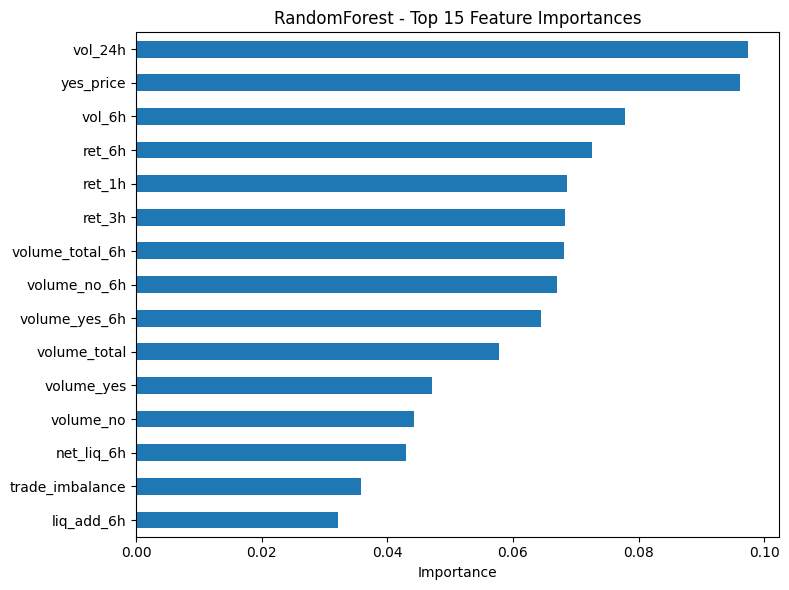

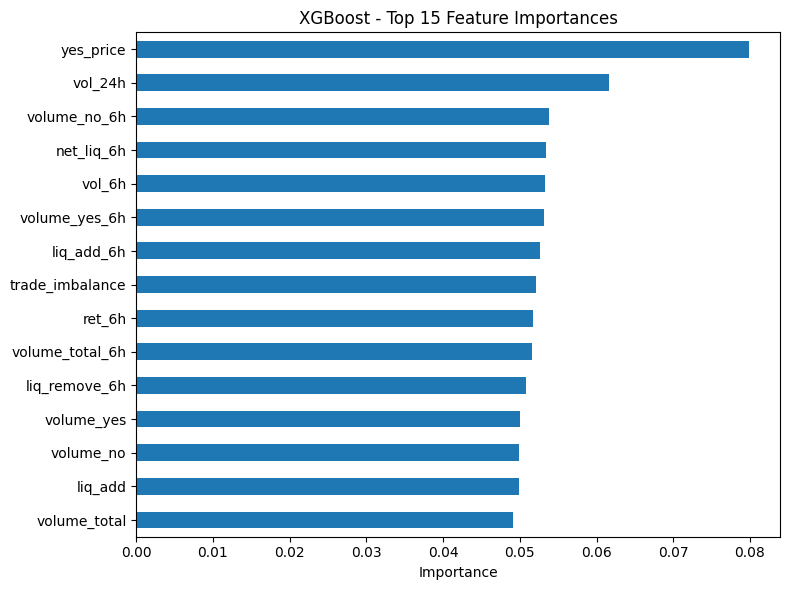

In [31]:
# 7.1 — Feature Importances (RandomForest & XGBoost)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RandomForest importances
rf_importances = rf_clf.feature_importances_
rf_imp_series = pd.Series(rf_importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
rf_imp_series.head(15).iloc[::-1].plot(kind="barh")
plt.title("RandomForest - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# XGBoost importances
xgb_importances = xgb_clf.feature_importances_
xgb_imp_series = pd.Series(xgb_importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
xgb_imp_series.head(15).iloc[::-1].plot(kind="barh")
plt.title("XGBoost - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Class names: ['DOWN', 'FLAT', 'UP']
Instance Index: 5
(True label mövcud deyil və ya y_val təyin olunmayıb)
Predicted class: FLAT
Probabilities:
  DOWN: 0.345
  FLAT: 0.392
  UP: 0.263


c:\Users\HP\Desktop\PredictBack\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\Desktop\PredictBack\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



LIME (feature → contribution):
  vol_24h <= 0.03: 0.0693
  liq_add_6h > 401.53: -0.0111
  vol_6h <= 0.03: 0.0084
  0.00 < ret_1h <= 0.02: 0.0078
  liq_add <= 0.00: 0.0059
  net_liq_6h > 295.04: -0.0058
  ret_3h <= -0.05: -0.0047
  trade_imbalance <= -0.67: -0.0040
  288.58 < volume_total <= 536.55: -0.0031
  ret_6h <= -0.07: 0.0029


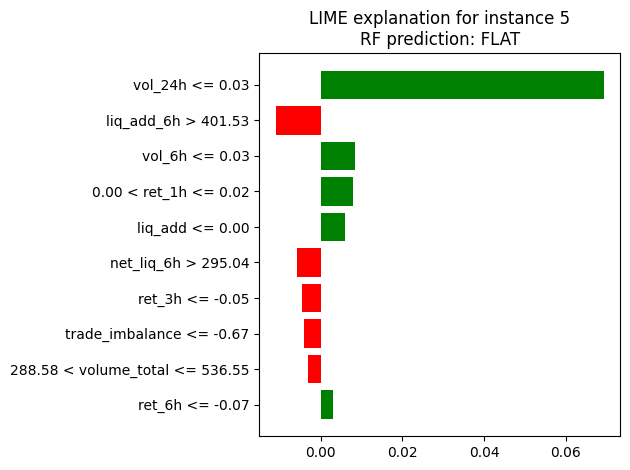

Instance Index: 20
(True label mövcud deyil və ya y_val təyin olunmayıb)
Predicted class: DOWN
Probabilities:
  DOWN: 0.371
  FLAT: 0.274
  UP: 0.355


c:\Users\HP\Desktop\PredictBack\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\Desktop\PredictBack\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



LIME (feature → contribution):
  vol_24h > 0.05: -0.0475
  vol_6h > 0.05: -0.0114
  liq_add_6h <= 0.00: 0.0079
  ret_6h > 0.06: -0.0073
  liq_add <= 0.00: 0.0071
  liq_remove_6h <= 0.00: 0.0067
  0.29 < yes_price <= 0.47: 0.0038
  -0.03 < ret_1h <= 0.00: 0.0033
  net_liq_6h <= 0.00: 0.0030
  2425.52 < volume_total_6h <= 3524.46: 0.0026


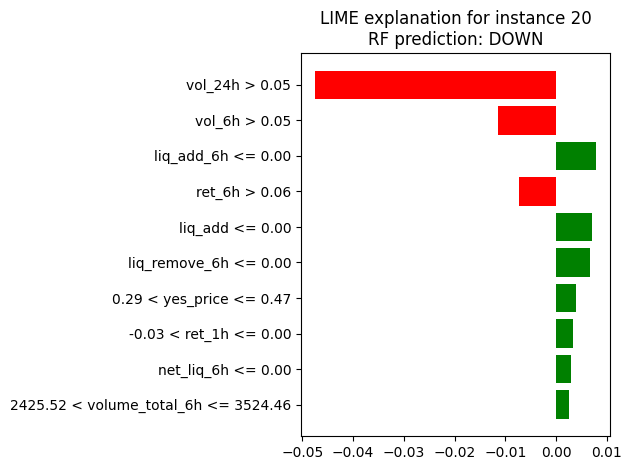

Instance Index: 50
(True label mövcud deyil və ya y_val təyin olunmayıb)
Predicted class: UP
Probabilities:
  DOWN: 0.343
  FLAT: 0.276
  UP: 0.381


c:\Users\HP\Desktop\PredictBack\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\Desktop\PredictBack\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



LIME (feature → contribution):
  0.04 < vol_24h <= 0.05: -0.0346
  liq_add_6h <= 0.00: 0.0094
  trade_imbalance <= -0.67: -0.0066
  yes_price <= 0.29: -0.0040
  0.03 < vol_6h <= 0.04: 0.0037
  volume_total > 838.22: 0.0036
  liq_remove <= 0.00: 0.0035
  volume_no_6h > 2616.66: -0.0033
  volume_no > 477.33: 0.0031
  liq_remove_6h <= 0.00: 0.0029


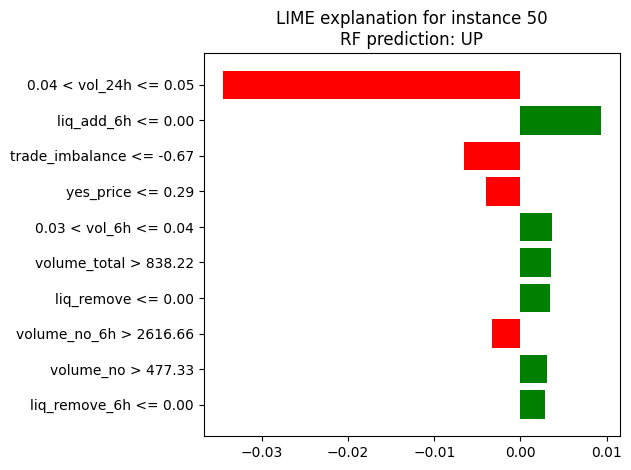

In [41]:
# 7.2 — Local Explainability with LIME (for RandomForest model)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

# Əmin olaq ki, numpy array formatındadır
X_train_np = np.array(X_train)
X_val_np = np.array(X_val)

# RF classifier-in class adları (məs: ['DOWN', 'FLAT', 'UP'])
class_names = [str(c) for c in rf_clf.classes_]
print("Class names:", class_names)

# LIME explainer qururuq
explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_cols,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True
)

def rf_predict_proba(x: np.ndarray) -> np.ndarray:
    """
    LIME üçün wrapper.
    x: numpy array, shape = (n_samples, n_features)
    return: predict_proba nəticəsi, shape = (n_samples, n_classes)
    """
    x_df = pd.DataFrame(x, columns=feature_cols)
    return rf_clf.predict_proba(x_df)

def explain_instance_with_plot(idx: int):
    """
    Verilmiş idx üçün LIME izahını və RF proqnozunu göstərir.
    """
    x_instance = X_val_np[idx]

    # ---- Model proqnozu ----
    proba = rf_predict_proba(x_instance.reshape(1, -1))[0]
    pred_class_idx = int(np.argmax(proba))
    pred_class = class_names[pred_class_idx]

    print("=" * 60)
    print(f"Instance Index: {idx}")
    try:
        print(f"True label     : {y_val.iloc[idx]}")
    except Exception:
        print("(True label mövcud deyil və ya y_val təyin olunmayıb)")
    print(f"Predicted class: {pred_class}")
    print("Probabilities:")
    for cname, p in zip(class_names, proba):
        print(f"  {cname}: {p:.3f}")

    # ---- LIME explanation ----
    exp = explainer.explain_instance(
        data_row=x_instance,
        predict_fn=rf_predict_proba,
        num_features=10
    )

    # Burda label vermirik → LIME avtomatik ən güclü class-ı seçəcək
    print("\nLIME (feature → contribution):")
    for feat, weight in exp.as_list():
        print(f"  {feat}: {weight:.4f}")

    # ---- Plot şəklində vizualizasiya ----
    fig = exp.as_pyplot_figure()
    plt.title(
        f"LIME explanation for instance {idx}\n"
        f"RF prediction: {pred_class}"
    )
    plt.tight_layout()
    plt.show()

# ===============================
# 3 nümunə üçün test edək
# ===============================

indices_to_try = [5, 20, 50]  # istədiyin index-ləri yaza bilərsən

for idx in indices_to_try:
    if idx < len(X_val_np):
        explain_instance_with_plot(idx)
    else:
        print(f"Index {idx} X_val uzunluğunu keçir, skipped.")


In [43]:
def compute_risk_score(class_proba, class_order):
    # class_order məsələn: ["DOWN", "FLAT", "UP"]
    p_down = class_proba[class_order.index("DOWN")]
    p_up = class_proba[class_order.index("UP")]
    risk = (p_down + p_up) * 50  # max 100
    return risk

class_order = list(gb_clf.classes_)  # məsələn ['DOWN','FLAT','UP']

# nümunə:
proba_example = gb_clf.predict_proba(X_test[0:1])[0]
risk_score_example = compute_risk_score(proba_example, class_order)
print("Example probs:", proba_example)
print("Risk score:", risk_score_example)

Example probs: [0.37145805 0.24471912 0.38382283]
Risk score: 37.764044159073805


In [44]:
def compute_risk_score(class_proba, class_order):
    # class_order məsələn: ["DOWN", "FLAT", "UP"]
    p_down = class_proba[class_order.index("DOWN")]
    p_up = class_proba[class_order.index("UP")]
    risk = (p_down + p_up) * 50  # max 100
    return risk

class_order = list(rf_clf.classes_)  # məsələn ['DOWN','FLAT','UP']

# nümunə:
proba_example = rf_clf.predict_proba(X_test[0:1])[0]
risk_score_example = compute_risk_score(proba_example, class_order)
print("Example probs:", proba_example)
print("Risk score:", risk_score_example)

Example probs: [0.31916144 0.30877231 0.37206626]
Risk score: 34.56138465559126


In [45]:
# 8. — Save Model 3 (XGBoost token behaviour model)

import joblib
import os

# Notebook yolu: predicthub_backend/ml/notebooks/
# Modellerin yolu: predicthub_backend/ml/models/
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

model3_path = os.path.join(models_dir, "model3_token_rf.pkl")
features_path = os.path.join(models_dir, "model3_token_rf_features.pkl")

joblib.dump(rf_clf, model3_path)
joblib.dump(feature_cols, features_path)

print(f"Model 3 saved to: {model3_path}")
print(f"Feature list saved to: {features_path}")

Model 3 saved to: ../models\model3_token_rf.pkl
Feature list saved to: ../models\model3_token_rf_features.pkl
